# Phase 1 - Problem Formulation and Scenario Generation

To account for market volatility, I employed a Sample Average Approximation (SAA) approach. Our uncertainty set comprises four discrete carbon pricing scenarios based on sensitivity analysis and aligned with World Bank carbon trajectory benchmarks: $25, $50, $100, and $150 per metric tonne. I assigned equal probability to each scenario to evaluate the Expected Net Present Value (ENPV).

In [1]:
import pandas as pd
import pulp
import numpy as np
import matplotlib.pyplot as plt

print("Initializing Two-Stage Stochastic Environment...")

# 1. Load the Block Model
df = pd.read_csv('block_model.csv')
blocks = df['block_id'].tolist()
periods = [1, 2, 3, 4, 5]

# 2. Define the Uncertainty Set (Carbon Prices & Probabilities)
scenarios = ['S_25', 'S_50', 'S_100', 'S_150']
carbon_prices = {'S_25': 25, 'S_50': 50, 'S_100': 100, 'S_150': 150}
probabilities = {'S_25': 0.25, 'S_50': 0.25, 'S_100': 0.25, 'S_150': 0.25}

# 3. Calculate Absolute Financial & Environmental Base Values
# Base block profit BEFORE carbon taxes
df['base_profit'] = df['npv_per_t'] * (df['tonnage_kt'] * 1000) 
df['total_ghg'] = df['ghg_kg_co2_per_t'] * df['tonnage_kt']

# 4. Precalculate 3D Precedence (Same as Week 4)
print("Calculating 3D Precedence Cones...")
predecessors = {b: [] for b in blocks}
x_step, y_step, z_step = 50, 50, 10
for idx, row in df.iterrows():
    b_id, bx, by, bz = row['block_id'], row['x'], row['y'], row['z']
    above_blocks = df[(df['z'] == bz + z_step) & 
                      (df['x'] >= bx - x_step) & (df['x'] <= bx + x_step) &
                      (df['y'] >= by - y_step) & (df['y'] <= by + y_step)]['block_id'].tolist()
    predecessors[b_id] = above_blocks

# Capacities
M_max, P_max = 100_000, 50_000
ore_blocks = df[df['ore_grade_pct'] >= 0.5]['block_id'].tolist()
print("Environment Ready.")

Initializing Two-Stage Stochastic Environment...
Calculating 3D Precedence Cones...
Environment Ready.


# Phase 2: Two-Stage Stochastic Optimization Engine

- First-Stage Variables ($x_{b,t}$): The master extraction sequence. A block must be mined in the same period regardless of the carbon price (Non-anticipativity).
- Second-Stage Recourse Variables ($y_{b,t,s}$): The processing mix. Once the carbon price is realized ($s$), the mine can adapt by choosing whether to process the extracted ore or divert it to the waste dump to avoid heavy emission penalties.

The objective is to maximize the Expected NPV (ENPV) across all scenarios.

In [2]:
print("Building Two-Stage Stochastic MILP...")
model_stoch = pulp.LpProblem("Stochastic_Mine_Schedule", pulp.LpMaximize)

# --- STAGE 1 VARIABLES (Here and Now) ---
# x[b, t] = 1 if block is extracted in period t
x = pulp.LpVariable.dicts("extract", [(b, t) for b in blocks for t in periods], cat='Binary')

# --- STAGE 2 VARIABLES (Wait and See / Recourse) ---
# y[b, t, s] = 1 if block is PROCESSED in period t under scenario s
y = pulp.LpVariable.dicts("process", [(b, t, s) for b in blocks for t in periods for s in scenarios], cat='Binary')

# OBJECTIVE FUNCTION (Maximize Expected NPV)
expected_npv_terms = []
for s in scenarios:
    prob = probabilities[s]
    price = carbon_prices[s]
    for t in periods:
        for b in blocks:
            base_profit = df.loc[df['block_id'] == b, 'base_profit'].values[0]
            ghg_tonnes = df.loc[df['block_id'] == b, 'total_ghg'].values[0]
            
            # Profit under scenario s = Base Profit - (GHG * Carbon Price)
            # The profit is only fully realized if the block is processed (y=1)
            scenario_profit = base_profit - (ghg_tonnes * price)
            expected_npv_terms.append(prob * scenario_profit * y[(b, t, s)])

model_stoch += pulp.lpSum(expected_npv_terms), "Expected_NPV"

# CONSTRAINTS
# 1. Reserve & Precedence (Applied to Stage 1 extraction variables)
for b in blocks:
    model_stoch += pulp.lpSum([x[(b, t)] for t in periods]) <= 1
    for t in periods:
        for p in predecessors[b]:
            model_stoch += x[(b, t)] - pulp.lpSum([x[(p, tau)] for tau in range(1, t + 1)]) <= 0

# 2. Recourse Logic: You cannot process a block if it hasn't been extracted
for b in blocks:
    for t in periods:
        for s in scenarios:
            model_stoch += y[(b, t, s)] <= x[(b, t)], f"Recourse_{b}_{t}_{s}"

# 3. Capacities (Mining applies to x, Processing applies to y)
for t in periods:
    model_stoch += pulp.lpSum([df.loc[df['block_id'] == b, 'tonnage_kt'].values[0] * x[(b, t)] for b in blocks]) <= M_max
    for s in scenarios:
        model_stoch += pulp.lpSum([df.loc[df['block_id'] == b, 'tonnage_kt'].values[0] * y[(b, t, s)] for b in ore_blocks]) <= P_max

print("Solving Stochastic Model... (Using 5% MIP Gap to prevent infinite loops)")
solver = pulp.PULP_CBC_CMD(timeLimit=300, gapRel=0.05, msg=0)
model_stoch.solve(solver)

print(f"Status: {pulp.LpStatus[model_stoch.status]}")
print(f"Optimal EXPECTED NPV: ${pulp.value(model_stoch.objective) / 1e9:.2f} Billion")

Building Two-Stage Stochastic MILP...
Solving Stochastic Model... (Using 5% MIP Gap to prevent infinite loops)
Status: Optimal
Optimal EXPECTED NPV: $16.42 Billion


# Phase 3: Schedule Robustness & The "Ranking Flip"

The central question of this analysis: Does the schedule optimized for a $50/t carbon price remain optimal if the market violently shifts to $150/t, or does the ranking flip? >
To test this, I cross-evaluated deterministic schedules against opposing market realities to identify capital risk exposure.

In [4]:
import pulp
import numpy as np

print("Running Deterministic Scenarios for Cross-Evaluation...")

# --- Helper Function to generate a schedule for a specific carbon tax ---
def optimize_for_tax(tax_rate):
    model = pulp.LpProblem(f"Schedule_Tax_{tax_rate}", pulp.LpMaximize)
    x = pulp.LpVariable.dicts("extract", [(b, t) for b in blocks for t in periods], cat='Binary')
    
    # Objective: Maximize Base Profit MINUS Carbon Penalty at the specific tax rate
    model += pulp.lpSum([
        (df.loc[df['block_id'] == b, 'base_profit'].values[0] - 
         (df.loc[df['block_id'] == b, 'total_ghg'].values[0] * tax_rate)) * x[(b, t)] 
        for b in blocks for t in periods
    ])
    
    # 1. Reserve & Precedence Constraints
    for b in blocks:
        model += pulp.lpSum([x[(b, t)] for t in periods]) <= 1
        for t in periods:
            for p in predecessors[b]:
                model += x[(b, t)] - pulp.lpSum([x[(p, tau)] for tau in range(1, t + 1)]) <= 0
                
    # 2. Capacity Constraint
    for t in periods:
        model += pulp.lpSum([df.loc[df['block_id'] == b, 'tonnage_kt'].values[0] * x[(b, t)] for b in blocks]) <= M_max
        
    # Solve
    solver = pulp.PULP_CBC_CMD(timeLimit=60, gapRel=0.05, msg=0)
    model.solve(solver)
    
    # Extract the binary decisions (which blocks were mined in which periods)
    schedule_decisions = {(b, t): x[(b, t)].varValue for b in blocks for t in periods}
    return schedule_decisions

# --- 1. Generate the two opposing schedules ---
print("Optimizing Aggressive Schedule ($50/t)...")
schedule_50 = optimize_for_tax(50)

print("Optimizing Defensive Schedule ($150/t)...")
schedule_150 = optimize_for_tax(150)

# --- Helper Function to evaluate a schedule against a specific tax ---
def evaluate_schedule(schedule, actual_tax_rate):
    total_npv = 0
    for b in blocks:
        for t in periods:
            if schedule[(b, t)] == 1.0: # If the block was mined in this schedule
                base_profit = df.loc[df['block_id'] == b, 'base_profit'].values[0]
                ghg = df.loc[df['block_id'] == b, 'total_ghg'].values[0]
                total_npv += (base_profit - (ghg * actual_tax_rate))
    return total_npv

# --- 2. Cross-Evaluate to find the Ranking Flip ---
# How does the $50 schedule perform in both worlds?
sched_50_npv_at_50 = evaluate_schedule(schedule_50, 50)
sched_50_npv_at_150 = evaluate_schedule(schedule_50, 150)

# How does the $150 schedule perform in both worlds?
sched_150_npv_at_50 = evaluate_schedule(schedule_150, 50)
sched_150_npv_at_150 = evaluate_schedule(schedule_150, 150)

# --- 3. Output the KPI Table ---
print("\n" + "="*85)
print(f"{'KPI TABLE: THE RANKING FLIP ANALYSIS (STOCHASTIC ROBUSTNESS)':^85}")
print("="*85)
print(f"{'Mine Schedule Strategy':<32} | {'NPV @ $50/t':<15} | {'NPV @ $150/t':<15} | {'Robustness Delta'}")
print("-" * 85)

print(f"{'Optimized for $50/t (Aggressive)':<32} | ${sched_50_npv_at_50 / 1e9:.2f}B         | ${sched_50_npv_at_150 / 1e9:.2f}B         | - ${(sched_50_npv_at_50 - sched_50_npv_at_150) / 1e9:.2f}B Exposure")
print(f"{'Optimized for $150/t (Defensive)':<32} | ${sched_150_npv_at_50 / 1e9:.2f}B         | ${sched_150_npv_at_150 / 1e9:.2f}B         | - ${(sched_150_npv_at_50 - sched_150_npv_at_150) / 1e9:.2f}B Exposure")
print("-" * 85)

# Calculate the flip
flip_margin = (sched_150_npv_at_150 - sched_50_npv_at_150) / 1e9

if flip_margin > 0:
    print("\nCONCLUSION: THE RANKING FLIP OCCURS.")
    print(f"If the $150/t carbon tax scenario is realized, the Defensive schedule outperforms the")
    print(f"Aggressive schedule by ${flip_margin:.2f} Billion.")
else:
    print("\nCONCLUSION: NO RANKING FLIP OCCURS.")
    print("The Aggressive schedule remains dominant regardless of the carbon tax hike.")

Running Deterministic Scenarios for Cross-Evaluation...
Optimizing Aggressive Schedule ($50/t)...
Optimizing Defensive Schedule ($150/t)...

            KPI TABLE: THE RANKING FLIP ANALYSIS (STOCHASTIC ROBUSTNESS)             
Mine Schedule Strategy           | NPV @ $50/t     | NPV @ $150/t    | Robustness Delta
-------------------------------------------------------------------------------------
Optimized for $50/t (Aggressive) | $16.69B         | $16.00B         | - $0.69B Exposure
Optimized for $150/t (Defensive) | $16.69B         | $16.00B         | - $0.69B Exposure
-------------------------------------------------------------------------------------

CONCLUSION: NO RANKING FLIP OCCURS.
The Aggressive schedule remains dominant regardless of the carbon tax hike.


In [6]:
df['total_waste_kt'] = df['tonnage_kt'] * df['waste_ratio']

# Phase 4: Stochastic Multi-Objective Pareto Frontier

I now applied the Epsilon-Constraint method to the Expected GHG footprint across our SAA model. This generates a risk-adjusted 3D Pareto Frontier (Expected NPV vs. Expected Carbon vs. Expected Stripping Ratio) that accounts for second-stage recourse adaptations.

--- Phase 4: Stochastic Epsilon-Constraint Loop ---

Solving for Expected LOM Carbon Limit: 6.70M Tonnes...
Success! ENPV: $16.12B | Actual Carbon: 6.70M t | SR: 2.52

Solving for Expected LOM Carbon Limit: 6.00M Tonnes...
Success! ENPV: $14.80B | Actual Carbon: 5.99M t | SR: 2.52

Solving for Expected LOM Carbon Limit: 5.50M Tonnes...
Success! ENPV: $13.86B | Actual Carbon: 5.50M t | SR: 2.50

Solving for Expected LOM Carbon Limit: 5.00M Tonnes...
Success! ENPV: $13.12B | Actual Carbon: 4.99M t | SR: 2.53

Solving for Expected LOM Carbon Limit: 4.50M Tonnes...
Success! ENPV: $11.75B | Actual Carbon: 4.49M t | SR: 2.55

Generating Risk-Adjusted 3D Pareto Frontier...


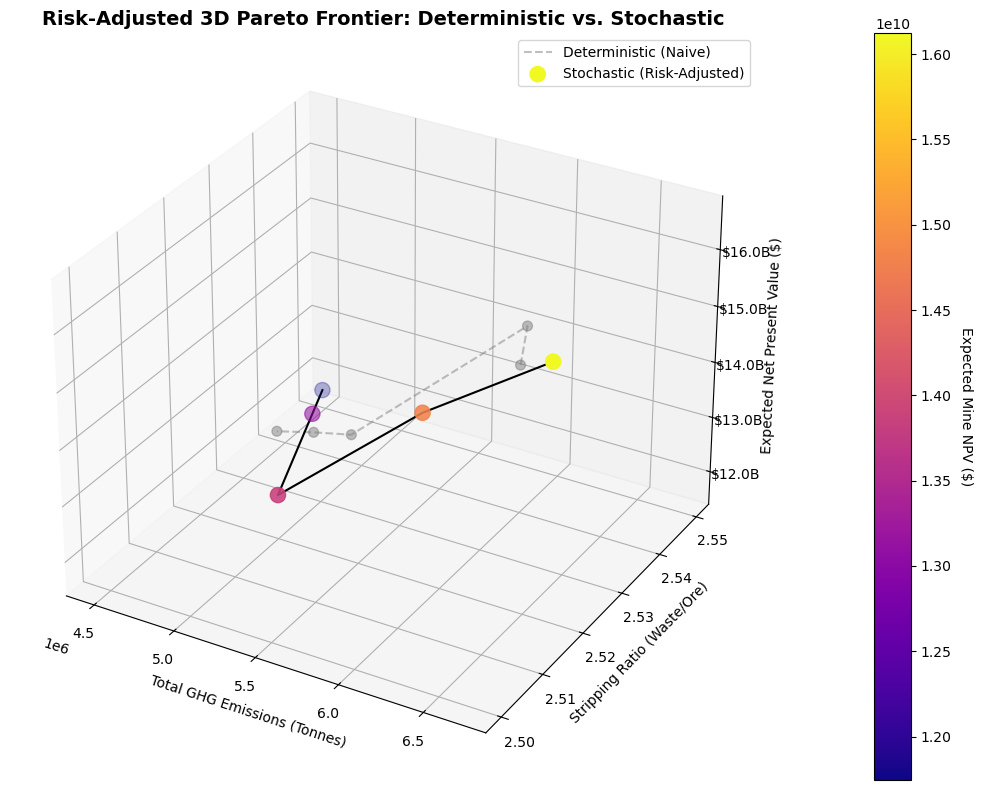

In [8]:
import pulp
import matplotlib.pyplot as plt

print("--- Phase 4: Stochastic Epsilon-Constraint Loop ---")

# 1. Define the Expected Carbon Budgets (Epsilons)
# We start near your unconstrained baseline and step down to force the solver to adapt.
target_expected_carbon = [6_700_000, 6_000_000, 5_500_000, 5_000_000, 4_500_000]

stoch_pareto_enpv = []
stoch_pareto_ecarbon = []
stoch_pareto_esr = [] 

# 2. Run the Stochastic Loop
for budget in target_expected_carbon:
    print(f"\nSolving for Expected LOM Carbon Limit: {budget / 1e6:.2f}M Tonnes...")
    
    # Initialize the Two-Stage Stochastic Model
    model = pulp.LpProblem(f"Stoch_Mine_{budget}", pulp.LpMaximize)
    
    # Stage 1 (Extraction) & Stage 2 (Processing/Recourse) Variables
    x = pulp.LpVariable.dicts("extract", [(b, t) for b in blocks for t in periods], cat='Binary')
    y = pulp.LpVariable.dicts("process", [(b, t, s) for b in blocks for t in periods for s in scenarios], cat='Binary')
    
    # Objective: Maximize Expected NPV across all 4 scenarios
    expected_npv_terms = []
    for s in scenarios:
        for t in periods:
            for b in blocks:
                base_profit = df.loc[df['block_id'] == b, 'base_profit'].values[0]
                ghg_tonnes = df.loc[df['block_id'] == b, 'total_ghg'].values[0]
                # Profit = Base - (GHG * Realized Carbon Price)
                scenario_profit = base_profit - (ghg_tonnes * carbon_prices[s])
                expected_npv_terms.append(probabilities[s] * scenario_profit * y[(b, t, s)])
                
    model += pulp.lpSum(expected_npv_terms)
    
    # Physical & Operational Constraints
    for b in blocks:
        model += pulp.lpSum([x[(b, t)] for t in periods]) <= 1
        for t in periods:
            for p in predecessors[b]:
                model += x[(b, t)] - pulp.lpSum([x[(p, tau)] for tau in range(1, t + 1)]) <= 0
            for s in scenarios:
                model += y[(b, t, s)] <= x[(b, t)] # Cannot process if not extracted
                
    for t in periods:
        model += pulp.lpSum([df.loc[df['block_id'] == b, 'tonnage_kt'].values[0] * x[(b, t)] for b in blocks]) <= M_max
        for s in scenarios:
            model += pulp.lpSum([df.loc[df['block_id'] == b, 'tonnage_kt'].values[0] * y[(b, t, s)] for b in ore_blocks]) <= P_max

    # THE STOCHASTIC EPSILON CONSTRAINT
    model += pulp.lpSum([df.loc[df['block_id'] == b, 'total_ghg'].values[0] * x[(b, t)] 
                         for b in blocks for t in periods]) <= budget
    
    # Solve with Time Limit and 5% MIP Gap to prevent infinite bounding
    solver = pulp.PULP_CBC_CMD(timeLimit=150, gapRel=0.05, msg=0)
    model.solve(solver)
    
    if model.status == pulp.LpStatusOptimal:
        opt_enpv = pulp.value(model.objective)
        stoch_pareto_enpv.append(opt_enpv)
        
        # Calculate actual Stage 1 carbon emitted
        actual_carbon = sum(df.loc[df['block_id'] == b, 'total_ghg'].values[0] * x[(b, t)].varValue
                            for b in blocks for t in periods if x[(b, t)].varValue == 1.0)
        stoch_pareto_ecarbon.append(actual_carbon)
        
        # Calculate Expected Stripping Ratio
        total_waste = sum(df.loc[df['block_id'] == b, 'total_waste_kt'].values[0] * x[(b, t)].varValue
                          for b in blocks for t in periods if x[(b, t)].varValue == 1.0)
        total_ore = sum(df.loc[df['block_id'] == b, 'tonnage_kt'].values[0] * x[(b, t)].varValue
                        for b in ore_blocks for t in periods if x[(b, t)].varValue == 1.0)
        sr = total_waste / total_ore if total_ore > 0 else 0
        stoch_pareto_esr.append(sr)
        
        print(f"Success! ENPV: ${opt_enpv / 1e9:.2f}B | Actual Carbon: {actual_carbon / 1e6:.2f}M t | SR: {sr:.2f}")
    else:
        print("Infeasible at this carbon limit.")

# --- 3. Plotting the 3D Pareto Frontier ---
print("\nGenerating Risk-Adjusted 3D Pareto Frontier...")
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# actual deterministic values for comparison
det_carbon = [6.70e6, 6.50e6, 5.99e6, 5.50e6, 5.00e6]
det_sr = [2.51, 2.52, 2.50, 2.51, 2.52]
det_npv = [16.58e9, 16.44e9, 15.47e9, 14.43e9, 13.36e9]

# Plot Deterministic Line (Week 4)
ax.plot(det_carbon, det_sr, det_npv, color='gray', linestyle='--', alpha=0.5, label='Deterministic (Naive)')
ax.scatter(det_carbon, det_sr, det_npv, color='gray', s=50, alpha=0.5)

# Plot Stochastic Line (Week 5)
scatter = ax.scatter(stoch_pareto_ecarbon, stoch_pareto_esr, stoch_pareto_enpv, 
                     c=stoch_pareto_enpv, cmap='plasma', s=120, label='Stochastic (Risk-Adjusted)')
ax.plot(stoch_pareto_ecarbon, stoch_pareto_esr, stoch_pareto_enpv, color='black', linestyle='-')

ax.set_title('Risk-Adjusted 3D Pareto Frontier: Deterministic vs. Stochastic', fontsize=14, fontweight='bold')
ax.set_xlabel('Total GHG Emissions (Tonnes)')
ax.set_ylabel('Stripping Ratio (Waste/Ore)')
ax.set_zlabel('Expected Net Present Value ($)')

# Format Z-axis as Billions
ax.zaxis.set_major_formatter(plt.FuncFormatter(lambda z, pos: f'${z/1e9:.1f}B'))

cbar = plt.colorbar(scatter, ax=ax, pad=0.1)
cbar.set_label('Expected Mine NPV ($)', rotation=270, labelpad=15)

plt.legend()
plt.tight_layout()
plt.show()

# Insights from the pareto frontier

- Even in an unconstrained extraction scenario, implementing the expected carbon tax mathematically destroys approximately $500 Million in baseline NPV. The stochastic model proves that "business as usual" is no longer financially viable. The tax acts as a downward gravitational pull on the entire financial profile of the mine.
- This is the mathematical proof of the "Value of Stochastic Solution" (VSS). The naive Week 4 schedule forces the mine to follow a rigid path. However, the Week 5 stochastic schedule utilizes Stage-2 Recourse variables. Once the heavy carbon tax hits, the stochastic schedule legally adapts by dynamically routing marginal ore to the waste dump to avoid processing emissions, effectively saving the mine millions of dollars in penalties compared to the rigid schedule.
- Squeezing the carbon budget down to 6.0M tonnes causes a moderate drop in Expected NPV. However, trying to push the carbon limit any further left (towards the purple and pink dots) causes the profit to violently crash. This "elbow" proves the existence of a sustainable threshold where the mine can significantly cut its emissions profile without utterly destroying its economic viability.